In [1]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn

from matplotlib import pyplot as plt

In [2]:
pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)["coarse_label_name"].unique()

array(['aquatic_mammals', 'food_containers', 'small_mammals',
       'large_natural_outdoor_scenes', 'large_carnivores', 'vehicles_1',
       'people', 'flowers', 'medium_mammals', 'reptiles',
       'large_omnivores_and_herbivores', 'fruit_and_vegetables', 'trees',
       'household_furniture', 'vehicles_2', 'fish',
       'household_electrical_devices', 'large_man_made_outdoor_things',
       'insects', 'non_insect_invertebrates'], dtype=object)

In [3]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.1


SELECTED_GROUP = "people"

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_fine_labels(name):

    if "class" in name:
        label = int(name.replace("class", ""))
        return [label]
    df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[2, 11, 35, 46, 98]

In [6]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(100)).difference(SELECTED_CLASSES))

In [7]:
NOT_SELECTED_CLASSES

[0,
 1,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 99]

In [8]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [9]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("cifar100").input_transformation
ds_train = CIFAR100(root="../../datasets", download=False, train=True, transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = CIFAR100(root="../../datasets", download=False, train=False, transform=transform,  target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [10]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/40 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0520


  0%|          | 0/79 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0500


In [11]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        
        
        # max_logit_selected = logits[:, SELECTED_CLASSES].max(dim=1).values
        # max_logit_notselected = logits[:, NOT_SELECTED_CLASSES].max(dim=1).values

        # assert len(max_logit_selected.shape) == 1

        # return max_logit_selected - 0* max_logit_notselected
        
    
def construct_model():
    model = models.get_trained_model("cifar100-resnet18-v1")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 32, 32)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [12]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [13]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/79 [00:00<?, ?it/s]

0.9878010153770447

# Extract Activation

In [14]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass

def compute_logodd_winning(logits):

    return torch.sign(logits).detach() * logits

def compute_logits(logits):

    return logits

class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits


class LogOddSquared(OutputQuantity):
    def __call__(self, logits, targets):
        return (torch.sign(logits).detach() * logits).pow(2)

        
class LogOddPositiveClass(OutputQuantity):
    def __call__(self, logits, targets):
        return logits

        
class LogOddIfPositiveClass(OutputQuantity):
    def __call__(self, logits, targets):
        return (logits >= 0)*logits


class LogOddIfNegativeClass(OutputQuantity):
    def __call__(self, logits, targets):
        return (logits < 0)*logits


class LogOddTargetClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(2*targets-1) * logits
        

class BinaryCrossEntropyWinning(OutputQuantity):
    def __call__(self, logits, targets):
        winning_target = torch.sign(logits).detach()
        return - F.binary_cross_entropy_with_logits(logits, winning_target)



In [15]:
OUTPUT_QUANTITY = LogOddPositiveClass()

def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    data_loader=dl_train,
    output_quantity=OUTPUT_QUANTITY,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)

    try:
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        
        for batch in tqdm(data_loader, desc=f"[layer={layer}] extract act ctx (group={SELECTED_GROUP} wrt {output_quantity})"):
            x, y = batch
            x = x.to(device)


            logits = model(x)
            
            quantities = output_quantity(logits, y)
            
            (quantities).sum().backward()
            act = utils.interceptor.get_output(module)

            assert act.grad is not None
            ctx = act.grad
            
            output_dimensions = act.shape[1:]

            assert ctx.shape == act.shape

            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()

            selected_act, selected_ctx = utils.subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            

            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
 
    return arr_act, arr_ctx


# def extract_activation_context_for_task(
#     model: nn.Module,
#     layer: str,
#     data_loader=dl_train,
#     output_quantity=LogOddPositiveClass(),
#     seed=1,
#     device=DEVICE,
#     number_of_selected_spatial_locations=20,
#     strict_mode=False,
#     verbose=False
# ):
        
#     return attributors.extract_activation_context(
#         model=model,
#         layer=layer,
#         dataset=dataset,
#         data_loader=dl_train,
#         logit_modifier=LogOddWinningClass(),
#         rng=np.random.default_rng(seed=seed),
#         device=device,
#         number_of_selected_spatial_locations=20,
#         strict_mode=False,
#     )

    # arr_act_2, arr_neg_ctx = attributors.extract_activation_context(
    #     model=model,
    #     layer=layer,
    #     dataset=dataset,
    #     data_loader=dl_train,
    #     logit_modifier=LogOddIfNegativeClass(),
    #     rng=np.random.default_rng(seed=seed),
    #     device=device,
    #     number_of_selected_spatial_locations=20,
    #     strict_mode=False,
    # )

    # np.testing.assert_allclose(arr_act, arr_act_2)

    # arr_ctx = np.concatenate(
    #     [
    #         arr_pos_ctx[:, np.newaxis], 
    #         arr_neg_ctx[:, np.newaxis]
    #     ], axis=1
    # )
    # # print(arr_ctx.shape)
    # # raise
    # return arr_act, arr_ctx
    

def ano():

    arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer3",
        dl_train,
    )

    print(f"Sanity check: passed!")
ano()

[layer=layer3] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer3: output-dims=torch.Size([256, 8, 8])
Sanity check: passed!


# Construct Basis

In [36]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbsNormalized(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / (pca.eigvals[0] ** 0.5)
        arr_ctx = arr_ctx / (gradpca.eigvals[0] ** 0.5)


        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class SumSigmaASigmaACNormalizedBefore(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / (pca.eigvals[0] ** 0.5)
        arr_ctx = arr_ctx / (gradpca.eigvals[0] ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        cov = cov_ac + cov_a 
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class SumSigmaASigmaACSumNormalizedBefore(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / (np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / (np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        cov = cov_ac + cov_a 
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class SumSigmaASigmaCSigmaACNormalizedBefore(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

       

class SumSigmaASigmaCSigmaACNormalizedGammaBefore(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)

        
        gamma_a = np.linalg.norm(arr_act, axis=1).mean() - pca.eigvals[0]
        gamma_a = np.max([gamma_a, 0])
        
        gamma_c = np.linalg.norm(arr_ctx, axis=1).mean() - gradpca.eigvals[0]
        gamma_c = np.max([gamma_c, 0])
        
        arr_act = arr_act
        arr_ctx = arr_ctx


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = gamma_c * cov_a + gamma_a*cov_c \
            + (np.sqrt(gamma_a) * np.sqrt(gamma_c)) * cov_ac 
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
        
class SumSigmaASigmaACNormalizedBeforeSortedAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / (pca.eigvals[0] ** 0.5)
        arr_ctx = arr_ctx / (gradpca.eigvals[0] ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        cov = cov_ac + cov_a
        
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class SumSigmaASigmaACNormalizedAfter(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        cov_a = 2*(arr_act.T @ arr_act)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        lambda_star_a = np.linalg.eigvalsh(cov_a).max()
        lambda_star_ac =  np.abs(np.linalg.eigvalsh(cov_ac)).max()
        cov = cov_ac / lambda_star_ac + cov_a / lambda_star_a
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

        


class SumSigmaASigmaACNormalizedAfterSortedAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        cov_a = 2*(arr_act.T @ arr_act)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        lambda_star_a = np.linalg.eigvalsh(cov_a).max()
        lambda_star_ac =  np.abs(np.linalg.eigvalsh(cov_ac)).max()
        cov = cov_ac / lambda_star_ac + cov_a / lambda_star_a
        
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

    

In [31]:
np.sqrt(4)

2.0

[layer=layer1] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])


[layer=layer2] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer2: output-dims=torch.Size([128, 16, 16])


[layer=layer3] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer3: output-dims=torch.Size([256, 8, 8])


[layer=layer4] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 4, 4])


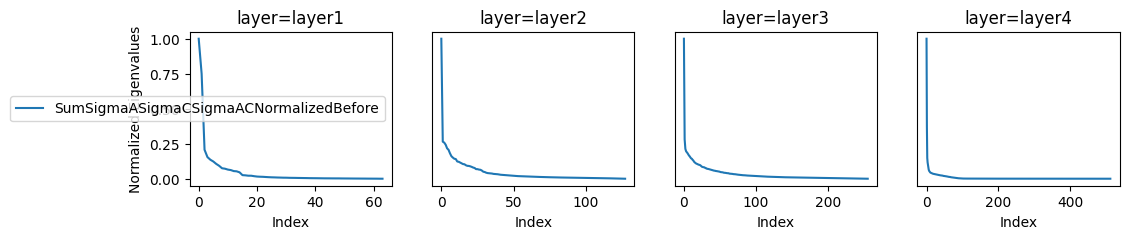

In [17]:
def viz_eigval_spectrum():

    def color_ls(basis_class):
        return {
            PCA: ("blue", "-"),
            GradPCA: ("blue", "--"),
            PRCASortAbs: ("red", "-"),
        }.get(basis_class, (None, None))
    arr_layers = [
        "layer1",
        "layer2",
        "layer3",
        "layer4",
    ]
    ncols = len(arr_layers)

    plt.figure(figsize=(3*ncols, 2))

    for lix, layer in enumerate(arr_layers):
            
        arr_act, arr_ctx = extract_activation_context_for_task(
            model, 
            layer,
            dl_train,
        )

        plt.subplot(1, ncols, lix + 1)
        plt.title(f"layer={layer}")
     
            
        for basis_class in [
            # PCA,
            # GradPCA,
            SumSigmaASigmaCSigmaACNormalizedBefore
        #     PRCASortAbs,
            # SumSigmaASigmaACNormalizedBefore,
            # SumSigmaASigmaACNormalizedAfter,
        ]:
            basis = basis_class(
                arr_act=arr_act,
                arr_ctx=arr_ctx
            )
            name = basis.__class__.__name__
            vals = basis.eigvals 
            color, ls = color_ls(basis_class)
            
            plt.plot(
                vals / np.max(vals), label=name,
                color=color,
                ls=ls
            )
        plt.xlabel("Index")
        if lix == 0:
            plt.ylabel("Normalized Eigenvalues")
            plt.legend()
        if lix > 0:
            plt.yticks([])

viz_eigval_spectrum()

In [25]:
# def viz_gamma():

#     def color_ls(basis_class):
#         return {
#             PCA: ("blue", "-"),
#             GradPCA: ("blue", "--"),
#             PRCASortAbs: ("red", "-"),
#         }.get(basis_class, (None, None))
#     arr_layers = [
#         "layer1",
#         "layer2",
#         "layer3",
#         "layer4",
#     ][:1]
#     ncols = len(arr_layers)
#     nrows = 2
#     plt.figure(figsize=(3*ncols, 2))

#     for lix, layer in enumerate(arr_layers):
            
#         arr_act, arr_ctx = extract_activation_context_for_task(
#             model, 
#             layer,
#             dl_train,
#         )

#         plt.subplot(1, ncols, lix + 1)
#         plt.title(f"layer={layer}")
     
            
#         for rix, (arr_vecs, basis_class) in enumerate([
#             (arr_act, PCA),
#             (arr_ctx, GradPCA),
#         ]):
#             basis = basis_class(
#                 arr_act=arr_act,
#                 arr_ctx=arr_ctx
#             )
#             name = basis.__class__.__name__
#             vals = basis.eigvals 
            
#             gamma = (np.linalg.norm(arr_vecs, axis=1) ** 2).mean() - basis.eigvals

#             plt.subplot(nrows, ncols, rix * ncols + lix + 1)
            
#             plt.plot(
#                 gamma,
#                 label=name,
#             )
#         plt.xlabel("Index")
#         if lix == 0:
#             plt.ylabel("Gamma")
#             plt.legend()
#         if lix > 0:
#             plt.yticks([])

# viz_gamma()

In [26]:
# def viz_eigval_spectrum_ratio():

  
#     arr_layers = [
#         "layer1",
#         "layer2",
#         "layer3",
#         "layer4",
#     ]
#     ncols = 1

#     plt.figure(figsize=(3*ncols, 2))

#     arr_vals = []
#     for lix, layer in enumerate(arr_layers):
            
#         arr_act, arr_ctx = extract_activation_context_for_task(
#             model, 
#             layer,
#             dl_train,
#         )

      
#         pca = PCA(
#             arr_act=arr_act,
#             arr_ctx=arr_ctx
#         )
#         gradpca = GradPCA(
#             arr_act=arr_act,
#             arr_ctx=arr_ctx
#         )
        
#         ratio = (np.max(gradpca.eigvals) / np.max(pca.eigvals)) ** 0.5

#         arr_vals.append(ratio)
        
#     plt.plot(arr_vals)
#     plt.ylabel(r"$\sqrt{\lambda_c / \lambda_a}$")

# viz_eigval_spectrum_ratio()

# Estimate Performance

In [37]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    arr_ks,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 

    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                layer=layer,
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)

                if hasattr(basis, "pre_filters") and len(basis.pre_filters) > 0:
                    print("we pre filter")
                    for filter_layer, filter_Uk in basis.pre_filters:
                        
                        layer_module = getattr(model, filter_layer)
                        hook = layer_module.register_forward_hook(
                            construct_fh(
                                torch.from_numpy(filter_Uk).float().to(DEVICE)
                            )
                        )
                        arr_hooks.append(hook)
                
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer4", 
    arr_basis_names=[
        SumSigmaASigmaCSigmaACNormalizedGammaBefore,
        PCA,
        GradPCA,
        
        PRCASortAbs,
        
        SumSigmaASigmaACNormalizedBefore,
        SumSigmaASigmaCSigmaACNormalizedBefore,
        # SumSigmaASigmaCSigmaACNormalizedGammaBefore,
        # SumSigmaASigmaACNormalizedBeforeSortedAbs,
        
        # SumSigmaASigmaACNormalizedAfter,
        # SumSigmaASigmaACNormalizedAfterSortedAbs,
    ],
    arr_ks=[ 
        1,
        5,
        # 10,
        # 15,
        20
    ],
)

[layer=layer4] extract act ctx (group=people wrt LogOddPositiveClass):   0%|          | 0/40 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 4, 4])


[SumSigmaASigmaCSigmaACNormalizedGammaBefore] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[                 PCA] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[         PRCASortAbs] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[SumSigmaASigmaACNormalizedBefore] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[SumSigmaASigmaCSigmaACNormalizedBefore] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,layer,k,basis_name,val_auroc
0,people,layer4,1,GradPCA,0.994154
0,people,layer4,1,SumSigmaASigmaCSigmaACNormalizedBefore,0.993581
0,people,layer4,1,SumSigmaASigmaACNormalizedBefore,0.961574
0,people,layer4,1,PRCASortAbs,0.559000
0,people,layer4,1,SumSigmaASigmaCSigmaACNormalizedGammaBefore,0.500000
0,people,layer4,1,PCA,0.500000
1,people,layer4,5,GradPCA,0.995086
1,people,layer4,5,SumSigmaASigmaCSigmaACNormalizedBefore,0.994384
1,people,layer4,5,PRCASortAbs,0.993617
1,people,layer4,5,SumSigmaASigmaACNormalizedBefore,0.959045


In [ ]:
# compute_task_aurocs_at_k(
#     model, layer="layer3", 
#     arr_basis_names=[
#         PCA,
#         GradPCA,
        
#         PRCASortAbs,
        
#         SumSigmaASigmaACNormalizedBefore,
#         SumSigmaASigmaACNormalizedBeforeSortedAbs,
        
#         SumSigmaASigmaACNormalizedAfter,
#         SumSigmaASigmaACNormalizedAfterSortedAbs,
#     ],
#     arr_ks=[ 
#         5,
#         10,
#         15,
#         20
#     ],
# )

In [ ]:
# compute_task_aurocs_at_k(
#     model, layer="layer1", 
#     arr_basis_names=[
#            PCA,
#         GradPCA,
        
#         PRCASortAbs,
        
#         SumSigmaASigmaACNormalizedBefore,
#         SumSigmaASigmaACNormalizedBeforeSortedAbs,
        
#         SumSigmaASigmaACNormalizedAfter,
#         SumSigmaASigmaACNormalizedAfterSortedAbs,
#     ],
#     arr_ks=[ 
#         1,
#         4,
#         5,
#         7,
#         # 15,
#         # 20
#     ],
# )

In [ ]:
# compute_task_aurocs_at_k(
#     model, layer="layer4", 
#     arr_basis_names=[
#         PCA,
#         GradPCA,
        
#         PRCASortAbs,
        
#         SumSigmaASigmaACNormalizedBefore,
#         SumSigmaASigmaACNormalizedBeforeSortedAbs,
        
#         SumSigmaASigmaACNormalizedAfter,
#         SumSigmaASigmaACNormalizedAfterSortedAbs,
#     ],
#     arr_ks=[ 
#         1,
#         5,
#         10,
#         # 15,
#         # 20
#     ],
# )

## Estimate Statistics

In [ ]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [ ]:
def estimate_stats(
    arr_basis_names=[
        # PCA,
        # GradPCA,
        
        # PRCASortAbs,
        
        SumSigmaASigmaACNormalizedBefore,
        SumSigmaASigmaACSumNormalizedBefore,
        SumSigmaASigmaCSigmaACNormalizedBefore,

        # SumSigmaASigmaACNormalizedBeforeSortedAbs,
        
        # SumSigmaASigmaACNormalizedAfter,
        # SumSigmaASigmaACNormalizedAfterSortedAbs,
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    # arr_layers = ["layer1"]
    for layer in tqdm(arr_layers):
        d = LAYER_DIM_MAPPING[layer]
        arr_ks = np.linspace(1, 32, 10).astype(int)

        df = compute_task_aurocs_at_k(
            model, layer=layer, 
            arr_basis_names=arr_basis_names,
            arr_ks=arr_ks,
        )
        arr_dfs.append(df)
    return pd.concat(arr_dfs)
df_stats = estimate_stats()

In [ ]:
def viz(
    df, 
    arr_basis_names, 
    dict_ls_color_mapping={
        "PCA":         ("-", "blue"),
        "GradPCA":     (":", "blue"),
        "PRCA":        (":", "red"),
        "PRCASortAbs": ("--", "red"),
    }
):

    def ls_color_mapping(basis_name):
        return dict_ls_color_mapping.get(basis_name, (None, None))

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(5*ncols, 4))
    plt.suptitle(f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (DATA_SIZE={DATA_SIZE}, output={OUTPUT_QUANTITY})", y=1.05)

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        d = LAYER_DIM_MAPPING[layer]
        
        for bix, basis_name in enumerate(arr_basis_names):
            _df = df[(df.basis_name == basis_name) & (df.layer==layer)]
            assert _df.shape[0] > 0
            if bix == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
            
            ls, color = ls_color_mapping(basis_name)
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=basis_name,
                ls=ls,
                color=color
            )

        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats, 
    arr_basis_names = [
        # "PCA",
        # "GradPCA",
        # "PRCASortAbs",
        "SumSigmaASigmaACNormalizedBefore",
        "SumSigmaASigmaACSumNormalizedBefore",
        "SumSigmaASigmaCSigmaACNormalizedBefore"
    ],
     dict_ls_color_mapping={
         # "PCA": ("-", "blue"),
         # "GradPCA": (":", "blue"),
         # "PRCASortAbs": ("-", "red"),
         # "SumSigmaASigmaCSigmaACNormalizedBefore": ("-", "orange"),
         # "SumSigmaASigmaACNormalizedBefore": (":", "orange"),
    }
)